# Fraud Detection Model Evaluation

This notebook performs comprehensive evaluation of the fraud detection model predictions. It loads inference results from the date-wise partitioned output and evaluates model performance using various metrics.

**Key Features:**
- Load predictions from partitioned Parquet files
- Calculate classification metrics (precision, recall, F1-score, AUC)
- Analyze fraud detection performance across different time periods
- Generate ROC curves and confusion matrices
- Evaluate threshold optimization
- Analyze prediction distributions and patterns

## 1. Import Required Libraries

Import all necessary libraries for model evaluation and performance analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os
import warnings

# Machine learning and evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✅ Libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")
print(f"🤖 Sklearn imported for evaluation metrics")
print(f"📅 Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📊 Pandas version: 2.3.2
🔢 NumPy version: 2.2.6
📈 Matplotlib version: 3.10.6
🎨 Seaborn version: 0.13.2
🤖 Sklearn imported for evaluation metrics
📅 Analysis timestamp: 2025-11-07 11:44:42


## 2. Load Partitioned Predictions Data

Load the fraud predictions from the date-wise partitioned output generated by the inference script.

In [2]:
# Define the base path for partitioned predictions
# Update this path to match your actual output directory
base_predictions_path = "/root/research-dir/dev/jazzcash-fraud-detection/scripts/fraud_predictions_datewise_*"

print("🔍 Searching for prediction directories...")
print(f"📁 Search pattern: {base_predictions_path}")

# Find all prediction directories
prediction_dirs = glob.glob(base_predictions_path)
print(f"Found {len(prediction_dirs)} prediction directories:")

if prediction_dirs:
    # Use the most recent directory
    latest_dir = max(prediction_dirs, key=os.path.getctime)
    print(f"📂 Using latest directory: {latest_dir}")
    
    # Find all date partitions
    partition_pattern = f"{latest_dir}/cutoff_date=*/*.parquet"
    parquet_files = glob.glob(partition_pattern)
    
    print(f"📊 Found {len(parquet_files)} date partitions")
    
    if parquet_files:
        # Load all predictions from all dates
        print("📥 Loading predictions from all date partitions...")
        
        dfs = []
        for parquet_file in sorted(parquet_files):
            # Extract date from path
            cutoff_date = parquet_file.split('cutoff_date=')[1].split('/')[0]
            
            try:
                df_temp = pd.read_parquet(parquet_file)
                # Add cutoff_date column if not present
                if 'cutoff_date' not in df_temp.columns:
                    df_temp['cutoff_date'] = cutoff_date
                dfs.append(df_temp)
                print(f"   ✅ Loaded {len(df_temp):,} predictions for {cutoff_date}")
            except Exception as e:
                print(f"   ❌ Error loading {cutoff_date}: {str(e)}")
        
        if dfs:
            # Combine all dataframes
            df_predictions = pd.concat(dfs, ignore_index=True)
            print(f"\n🎯 Successfully loaded {len(df_predictions):,} total predictions")
            print(f"📅 Date range: {df_predictions['cutoff_date'].min()} to {df_predictions['cutoff_date'].max()}")
            print(f"📊 Columns: {list(df_predictions.columns)}")
        else:
            print("❌ No valid prediction files found!")
    else:
        print("❌ No parquet files found in the prediction directories!")
else:
    print("❌ No prediction directories found!")
    print("Please check that the inference script has been run and generated predictions.")

🔍 Searching for prediction directories...
📁 Search pattern: /root/research-dir/dev/jazzcash-fraud-detection/scripts/fraud_predictions_datewise_*
Found 1 prediction directories:
📂 Using latest directory: /root/research-dir/dev/jazzcash-fraud-detection/scripts/fraud_predictions_datewise_20251106_175352
📊 Found 31 date partitions
📥 Loading predictions from all date partitions...
   ✅ Loaded 5,328,768 predictions for 2025-07-01
   ✅ Loaded 6,204,479 predictions for 2025-07-02
   ✅ Loaded 6,424,704 predictions for 2025-07-03
   ✅ Loaded 6,157,829 predictions for 2025-07-04
   ✅ Loaded 5,651,610 predictions for 2025-07-05
   ✅ Loaded 4,578,588 predictions for 2025-07-06
   ✅ Loaded 6,193,072 predictions for 2025-07-07
   ✅ Loaded 6,242,652 predictions for 2025-07-08
   ✅ Loaded 6,362,401 predictions for 2025-07-09
   ✅ Loaded 6,590,160 predictions for 2025-07-10
   ✅ Loaded 6,755,635 predictions for 2025-07-11
   ✅ Loaded 6,957,604 predictions for 2025-07-12
   ✅ Loaded 6,620,481 predictions

## 3. Data Overview and Quality Check

Examine the loaded predictions data structure and perform quality checks.

In [3]:
# Check if predictions data exists
if 'df_predictions' in locals() and len(df_predictions) > 0:
    print("🔍 PREDICTIONS DATA OVERVIEW")
    print("=" * 50)
    
    # Basic info
    print(f"📊 Dataset Shape: {df_predictions.shape[0]:,} rows × {df_predictions.shape[1]} columns")
    print(f"💾 Memory Usage: {df_predictions.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print()
    
    # Column information
    print("📋 Column Information:")
    print("-" * 30)
    for i, (col, dtype) in enumerate(zip(df_predictions.columns, df_predictions.dtypes), 1):
        null_count = df_predictions[col].isnull().sum()
        null_pct = (null_count / len(df_predictions)) * 100
        print(f"{i:2d}. {col:<20} ({dtype}) - {null_count:,} nulls ({null_pct:.1f}%)")
    
    print()
    
    # Check if fraud_flag exists for evaluation
    has_fraud_flag = 'fraud_flag' in df_predictions.columns
    print(f"🎯 Ground Truth Available: {'✅ Yes' if has_fraud_flag else '❌ No'}")
    
    if has_fraud_flag:
        # Fraud flag distribution
        fraud_dist = df_predictions['fraud_flag'].value_counts().sort_index()
        total = len(df_predictions)
        print(f"📈 Fraud Distribution:")
        for label, count in fraud_dist.items():
            pct = (count / total) * 100
            status = "Legitimate" if label == 0 else "Fraud"
            print(f"   {status}: {count:,} ({pct:.2f}%)")
    
    # Prediction distribution
    if 'prediction' in df_predictions.columns:
        pred_dist = df_predictions['prediction'].value_counts().sort_index()
        print(f"🔮 Prediction Distribution:")
        for label, count in pred_dist.items():
            pct = (count / total) * 100
            status = "Predicted Legitimate" if label == 0 else "Predicted Fraud"
            print(f"   {status}: {count:,} ({pct:.2f}%)")
    
    # Date range analysis
    if 'cutoff_date' in df_predictions.columns:
        df_predictions['cutoff_date'] = pd.to_datetime(df_predictions['cutoff_date'])
        date_counts = df_predictions['cutoff_date'].value_counts().sort_index()
        print(f"\n📅 Date Range Analysis:")
        print(f"   First Date: {df_predictions['cutoff_date'].min().strftime('%Y-%m-%d')}")
        print(f"   Last Date: {df_predictions['cutoff_date'].max().strftime('%Y-%m-%d')}")
        print(f"   Total Days: {df_predictions['cutoff_date'].nunique()}")
        print(f"   Avg Predictions/Day: {len(df_predictions) / df_predictions['cutoff_date'].nunique():.0f}")
    
    print("\n👀 Sample Data:")
    display(df_predictions.head())
    
else:
    print("❌ No predictions data loaded. Please run the previous cell to load data.")
    print("Make sure the inference script has been run and generated predictions.")

🔍 PREDICTIONS DATA OVERVIEW
📊 Dataset Shape: 206,717,973 rows × 5 columns
💾 Memory Usage: 30556.95 MB

📋 Column Information:
------------------------------
 1. trans_id             (object) - 0 nulls (0.0%)
 2. fraud_flag           (int32) - 0 nulls (0.0%)
 3. prediction           (float64) - 0 nulls (0.0%)
 4. fraud_probability    (float64) - 0 nulls (0.0%)
 5. cutoff_date          (object) - 0 nulls (0.0%)

🎯 Ground Truth Available: ✅ Yes
📈 Fraud Distribution:
   Legitimate: 206,714,029 (100.00%)
   Fraud: 3,944 (0.00%)
🔮 Prediction Distribution:
   Predicted Legitimate: 206,703,890 (99.99%)
   Predicted Fraud: 14,083 (0.01%)

📅 Date Range Analysis:
   First Date: 2025-07-01
   Last Date: 2025-07-31
   Total Days: 31
   Avg Predictions/Day: 6668322

👀 Sample Data:


,trans_id,fraud_flag,prediction,fraud_probability,cutoff_date
0,83835428696,0,0.0,0.000031,2025-07-01
1,83900317190,0,0.0,0.000031,2025-07-01
2,83856567683,0,0.0,0.000031,2025-07-01
3,83857629374,0,0.0,0.000031,2025-07-01
4,83902098972,0,0.0,0.000031,2025-07-01


## 4. Model Performance Evaluation

Calculate comprehensive evaluation metrics for the fraud detection model.

In [5]:
# Evaluate model performance if ground truth is available
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns:
    
    print("📊 COMPREHENSIVE MODEL EVALUATION")
    print("=" * 50)
    
    # Extract true labels and predictions
    y_true = df_predictions['fraud_flag'].values
    y_pred = df_predictions['prediction'].values
    y_prob = df_predictions['fraud_probability'].values
    
    # Basic Classification Metrics
    print("🎯 Classification Metrics:")
    print("-" * 30)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}")
    
    # ROC AUC
    from sklearn.metrics import roc_auc_score
    roc_auc = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC:   {roc_auc:.4f}")
    
    # PR AUC
    pr_auc = average_precision_score(y_true, y_prob)
    print(f"PR AUC:    {pr_auc:.4f}")
    
    print("\n📋 Detailed Classification Report:")
    print("-" * 40)
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud']))
    # Confusion Matrix
    print("🔄 Confusion Matrix:")
    print("-" * 20)
    cm = confusion_matrix(y_true, y_pred)
    print(f"                 Predicted")
    print(f"               Legit  Fraud")
    print(f"Actual Legit   {cm[0,0]:>5}  {cm[0,1]:>5}")
    print(f"       Fraud   {cm[1,0]:>5}  {cm[1,1]:>5}")
    
    # Calculate rates
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)  # False Positive Rate
    fnr = fn / (fn + tp)  # False Negative Rate
    tpr = tp / (tp + fn)  # True Positive Rate (Recall)
    tnr = tn / (tn + fp)  # True Negative Rate (Specificity)
    
    print(f"\n📈 Detailed Rates:")
    print(f"True Positive Rate (Sensitivity):  {tpr:.4f}")
    print(f"True Negative Rate (Specificity):  {tnr:.4f}")
    print(f"False Positive Rate:               {fpr:.4f}")
    print(f"False Negative Rate:               {fnr:.4f}")
    
    # Business Impact Metrics
    print(f"\n💼 Business Impact Analysis:")
    print("-" * 30)
    total_transactions = len(df_predictions)
    actual_fraud = (y_true == 1).sum()
    predicted_fraud = (y_pred == 1).sum()
    correct_fraud_detected = tp
    missed_fraud = fn
    false_alarms = fp
    
    print(f"Total Transactions:        {total_transactions:,}")
    print(f"Actual Fraud Cases:        {actual_fraud:,}")
    print(f"Predicted Fraud Cases:     {predicted_fraud:,}")
    print(f"Correctly Detected Fraud:  {correct_fraud_detected:,}")
    print(f"Missed Fraud (False Neg):  {missed_fraud:,}")
    print(f"False Alarms (False Pos):  {false_alarms:,}")
    
    fraud_detection_rate = (correct_fraud_detected / actual_fraud) * 100
    false_alarm_rate = (false_alarms / (false_alarms + tn)) * 100
    
    print(f"Fraud Detection Rate:      {fraud_detection_rate:.2f}%")
    print(f"False Alarm Rate:          {false_alarm_rate:.2f}%")
    
else:
    print("❌ Cannot perform evaluation: Ground truth (fraud_flag) not available")
    print("This might be because:")
    print("1. No predictions data was loaded")
    print("2. The inference was run without include_fraud_flag=True")
    print("3. The data doesn't contain fraud_flag column")

📊 COMPREHENSIVE MODEL EVALUATION
🎯 Classification Metrics:
------------------------------
Accuracy:  0.9999 (99.99%)
Precision: 0.0000 (0.00%)
Recall:    0.0000 (0.00%)
F1-Score:  0.0000
Accuracy:  0.9999 (99.99%)
Precision: 0.0000 (0.00%)
Recall:    0.0000 (0.00%)
F1-Score:  0.0000
ROC AUC:   0.7895
ROC AUC:   0.7895
PR AUC:    0.0002

📋 Detailed Classification Report:
----------------------------------------
PR AUC:    0.0002

📋 Detailed Classification Report:
----------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00 206714029
       Fraud       0.00      0.00      0.00      3944

    accuracy                           1.00 206717973
   macro avg       0.50      0.50      0.50 206717973
weighted avg       1.00      1.00      1.00 206717973

🔄 Confusion Matrix:
--------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00 206714029
       Fraud   

## 5. Visualization: Performance Curves

Generate ROC curve, Precision-Recall curve, and other performance visualizations.

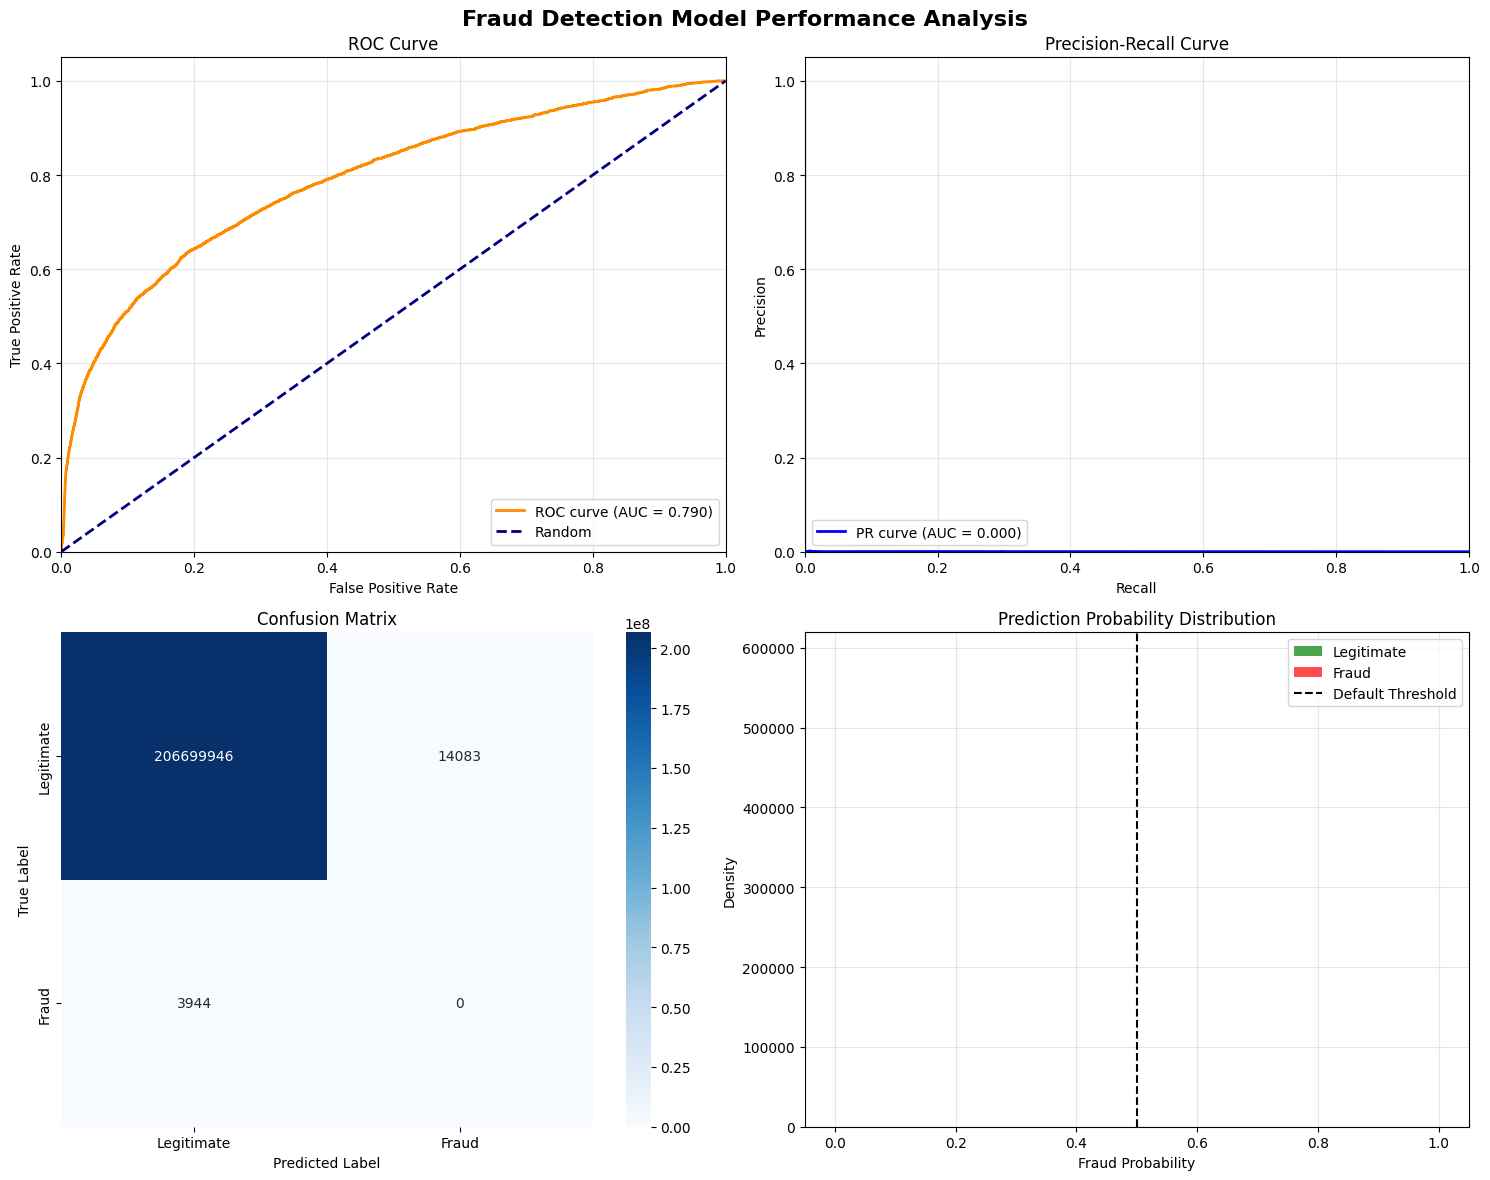

In [6]:
# Generate performance visualizations
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns:
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Fraud Detection Model Performance Analysis', fontsize=16, fontweight='bold')
    
    # Extract data
    y_true = df_predictions['fraud_flag'].values
    y_pred = df_predictions['prediction'].values
    y_prob = df_predictions['fraud_probability'].values
    
    # 1. ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[0, 0].set_xlim([0.0, 1.0])
    axes[0, 0].set_ylim([0.0, 1.05])
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve')
    axes[0, 0].legend(loc="lower right")
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    axes[0, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[0, 1].set_xlim([0.0, 1.0])
    axes[0, 1].set_ylim([0.0, 1.05])
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve')
    axes[0, 1].legend(loc="lower left")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xlabel('Predicted Label')
    
    # 4. Prediction Probability Distribution
    legitimate_probs = y_prob[y_true == 0]
    fraud_probs = y_prob[y_true == 1]
    
    axes[1, 1].hist(legitimate_probs, bins=50, alpha=0.7, label='Legitimate', density=True, color='green')
    axes[1, 1].hist(fraud_probs, bins=50, alpha=0.7, label='Fraud', density=True, color='red')
    axes[1, 1].axvline(x=0.5, color='black', linestyle='--', label='Default Threshold')
    axes[1, 1].set_xlabel('Fraud Probability')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].set_title('Prediction Probability Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Cannot generate visualizations: Ground truth not available")
    print("Please ensure the predictions include fraud_flag column for evaluation.")

## 6. Threshold Optimization

Analyze different probability thresholds to optimize the trade-off between precision and recall.

🎛️ THRESHOLD OPTIMIZATION ANALYSIS
🎯 Optimal Thresholds:
-------------------------
Best F1-Score:     0.100 (F1: 0.000)
Best Precision:    0.100 (Precision: 0.000)
Best Recall:       0.100 (Recall: 0.000)
🎯 Optimal Thresholds:
-------------------------
Best F1-Score:     0.100 (F1: 0.000)
Best Precision:    0.100 (Precision: 0.000)
Best Recall:       0.100 (Recall: 0.000)


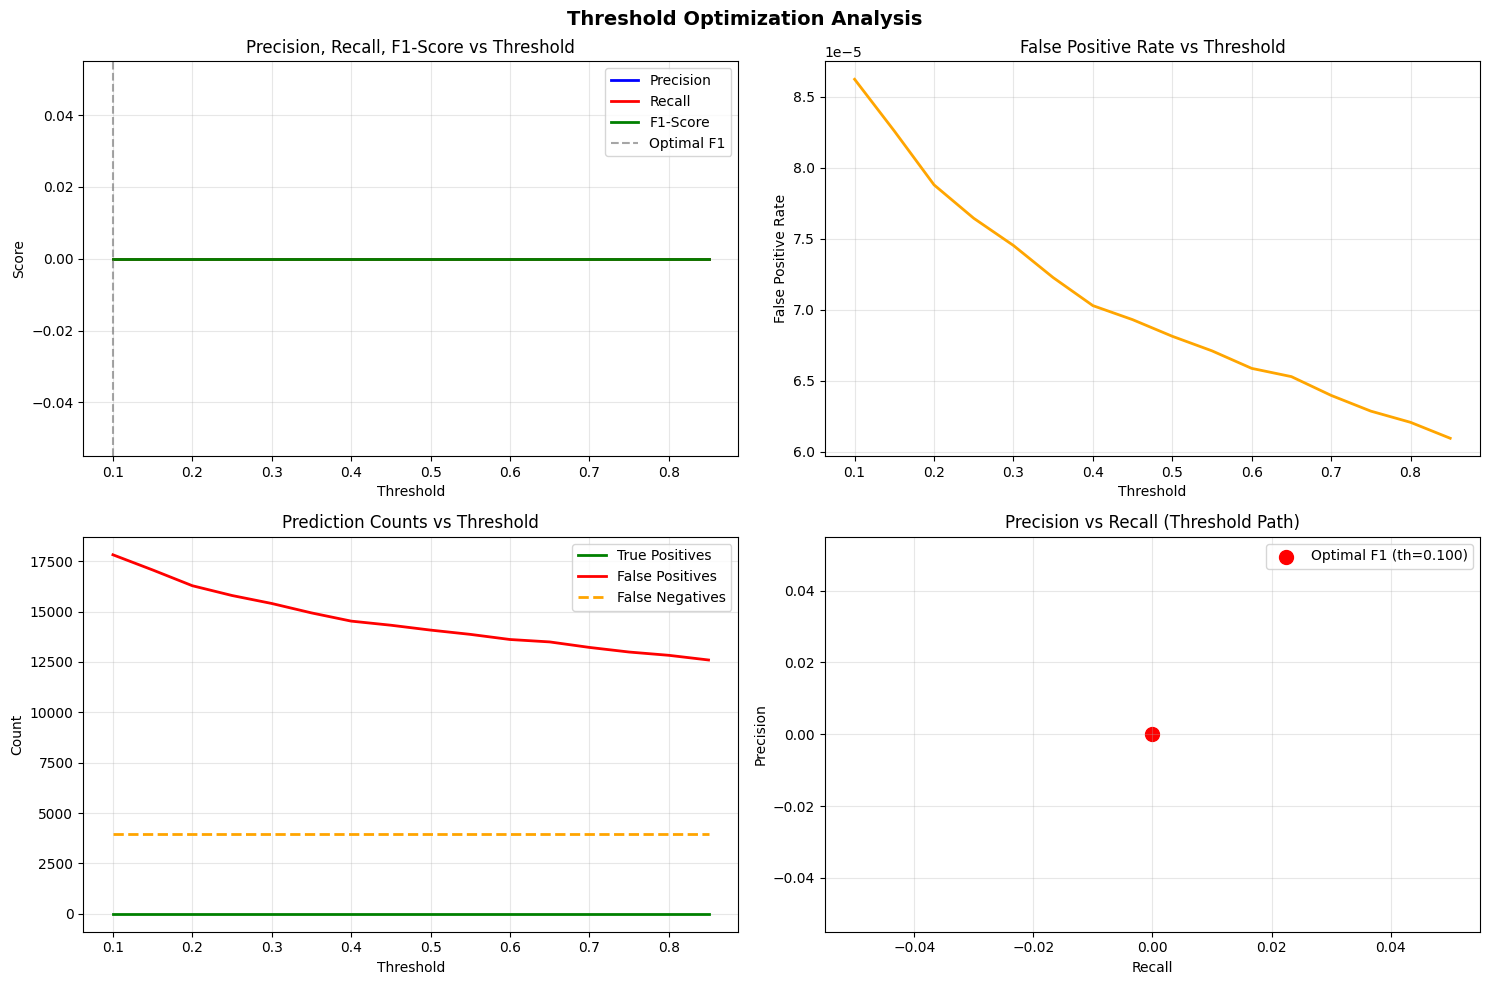

\n📊 Detailed Results for Key Thresholds:


,threshold,precision,recall,f1_score,accuracy,fpr
0,0.1,0.0,0.0,0.0,0.9999,0.0001


In [7]:
# Threshold optimization analysis
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns:
    
    print("🎛️ THRESHOLD OPTIMIZATION ANALYSIS")
    print("=" * 50)
    
    y_true = df_predictions['fraud_flag'].values
    y_prob = df_predictions['fraud_probability'].values
    
    # Test different thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    
    results = []
    for threshold in thresholds:
        y_pred_thresh = (y_prob >= threshold).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_true, y_pred_thresh, zero_division=0)
        recall = recall_score(y_true, y_pred_thresh)
        f1 = f1_score(y_true, y_pred_thresh, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred_thresh)
        
        # Calculate confusion matrix components
        cm = confusion_matrix(y_true, y_pred_thresh)
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'fpr': fpr,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results)
    
    # Find optimal thresholds for different criteria
    optimal_f1_idx = results_df['f1_score'].idxmax()
    optimal_precision_idx = results_df['precision'].idxmax()
    optimal_recall_idx = results_df['recall'].idxmax()
    
    print("🎯 Optimal Thresholds:")
    print("-" * 25)
    print(f"Best F1-Score:     {results_df.loc[optimal_f1_idx, 'threshold']:.3f} (F1: {results_df.loc[optimal_f1_idx, 'f1_score']:.3f})")
    print(f"Best Precision:    {results_df.loc[optimal_precision_idx, 'threshold']:.3f} (Precision: {results_df.loc[optimal_precision_idx, 'precision']:.3f})")
    print(f"Best Recall:       {results_df.loc[optimal_recall_idx, 'threshold']:.3f} (Recall: {results_df.loc[optimal_recall_idx, 'recall']:.3f})")
    
    # Plot threshold analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Threshold Optimization Analysis', fontsize=14, fontweight='bold')
    
    # Plot 1: Precision, Recall, F1-Score vs Threshold
    axes[0, 0].plot(results_df['threshold'], results_df['precision'], 'b-', label='Precision', linewidth=2)
    axes[0, 0].plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
    axes[0, 0].plot(results_df['threshold'], results_df['f1_score'], 'g-', label='F1-Score', linewidth=2)
    axes[0, 0].axvline(x=results_df.loc[optimal_f1_idx, 'threshold'], color='gray', linestyle='--', alpha=0.7, label='Optimal F1')
    axes[0, 0].set_xlabel('Threshold')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Precision, Recall, F1-Score vs Threshold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: False Positive Rate vs Threshold
    axes[0, 1].plot(results_df['threshold'], results_df['fpr'], 'orange', linewidth=2)
    axes[0, 1].set_xlabel('Threshold')
    axes[0, 1].set_ylabel('False Positive Rate')
    axes[0, 1].set_title('False Positive Rate vs Threshold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Number of Predictions vs Threshold
    axes[1, 0].plot(results_df['threshold'], results_df['tp'], 'g-', label='True Positives', linewidth=2)
    axes[1, 0].plot(results_df['threshold'], results_df['fp'], 'r-', label='False Positives', linewidth=2)
    axes[1, 0].plot(results_df['threshold'], results_df['fn'], 'orange', linestyle='--', label='False Negatives', linewidth=2)
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Prediction Counts vs Threshold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Precision vs Recall (PR Space)
    axes[1, 1].plot(results_df['recall'], results_df['precision'], 'b-', linewidth=2)
    axes[1, 1].scatter(results_df.loc[optimal_f1_idx, 'recall'], 
                       results_df.loc[optimal_f1_idx, 'precision'], 
                       color='red', s=100, label=f'Optimal F1 (th={results_df.loc[optimal_f1_idx, "threshold"]:.3f})')
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('Precision vs Recall (Threshold Path)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show detailed results table for key thresholds
    print("\\n📊 Detailed Results for Key Thresholds:")
    key_thresholds = [0.3, 0.5, 0.7, results_df.loc[optimal_f1_idx, 'threshold']]
    key_results = results_df[results_df['threshold'].isin([round(t, 3) for t in key_thresholds])]
    display(key_results[['threshold', 'precision', 'recall', 'f1_score', 'accuracy', 'fpr']].round(4))
    
else:
    print("❌ Cannot perform threshold optimization: Ground truth not available")

## 7. Time-Based Performance Analysis

Analyze model performance across different dates to identify temporal patterns and stability.

📅 TIME-BASED PERFORMANCE ANALYSIS
📊 Daily Performance Summary:
   Total Days Analyzed: 31
   Date Range: 2025-07-01 to 2025-07-31
   Avg Transactions/Day: 6668322
   Avg Fraud Rate: 0.00%
📊 Daily Performance Summary:
   Total Days Analyzed: 31
   Date Range: 2025-07-01 to 2025-07-31
   Avg Transactions/Day: 6668322
   Avg Fraud Rate: 0.00%


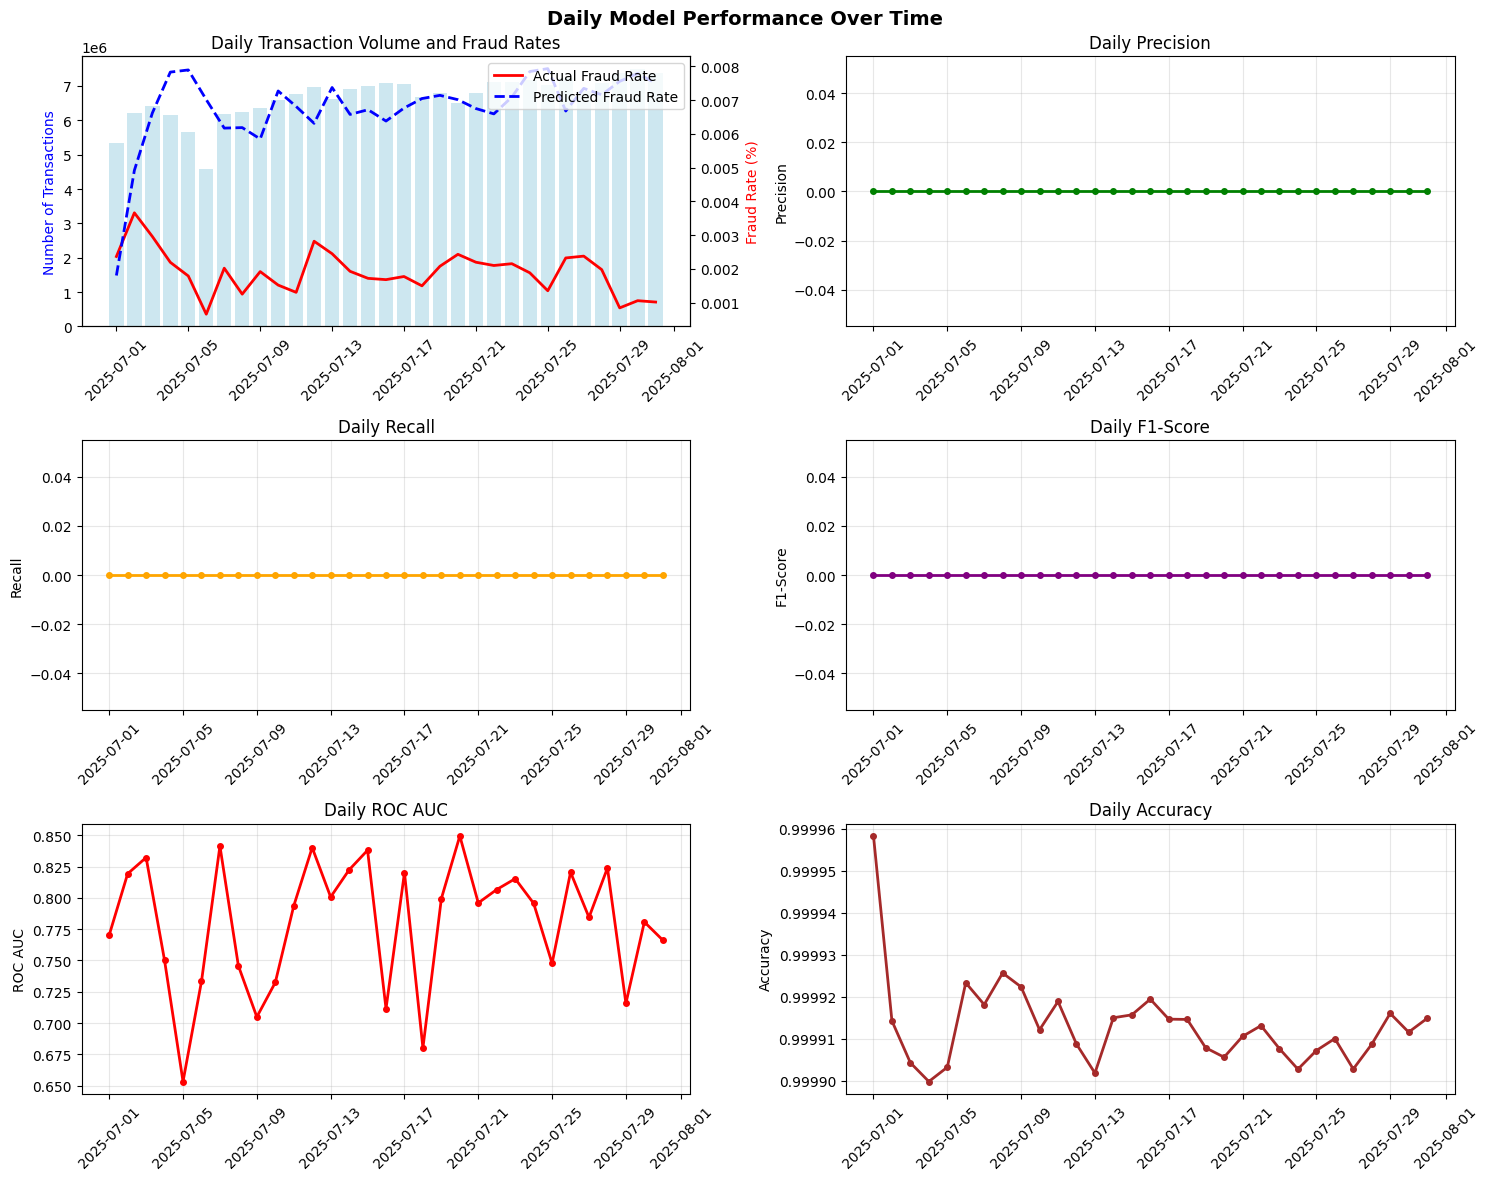

\n📈 Performance Statistics Across All Days:


,precision,recall,f1_score,accuracy,roc_auc,pr_auc
count,31.0,31.0,31.0,31.0000,31.0000,31.0000
mean,0.0,0.0,0.0,0.9999,0.7804,0.0003
std,0.0,0.0,0.0,0.0000,0.0513,0.0003
min,0.0,0.0,0.0,0.9999,0.6532,0.0000
25%,0.0,0.0,0.0,0.9999,0.7467,0.0001
50%,0.0,0.0,0.0,0.9999,0.7957,0.0002
75%,0.0,0.0,0.0,0.9999,0.8204,0.0003
max,0.0,0.0,0.0,1.0000,0.8496,0.0015


\n🏆 Best and Worst Performance Days:
Best F1-Score Day: 2025-07-01 (F1: 0.000)
Worst F1-Score Day: 2025-07-01 (F1: 0.000)


In [8]:
# Time-based performance analysis
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns and 'cutoff_date' in df_predictions.columns:
    
    print("📅 TIME-BASED PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Ensure cutoff_date is datetime
    df_predictions['cutoff_date'] = pd.to_datetime(df_predictions['cutoff_date'])
    
    # Calculate daily metrics
    daily_metrics = []
    
    for date in sorted(df_predictions['cutoff_date'].unique()):
        day_data = df_predictions[df_predictions['cutoff_date'] == date]
        
        if len(day_data) > 0:
            y_true_day = day_data['fraud_flag'].values
            y_pred_day = day_data['prediction'].values
            y_prob_day = day_data['fraud_probability'].values
            
            # Calculate metrics for this day
            n_transactions = len(day_data)
            n_fraud_actual = (y_true_day == 1).sum()
            n_fraud_predicted = (y_pred_day == 1).sum()
            
            if n_fraud_actual > 0:  # Only calculate if there are actual fraud cases
                precision = precision_score(y_true_day, y_pred_day, zero_division=0)
                recall = recall_score(y_true_day, y_pred_day)
                f1 = f1_score(y_true_day, y_pred_day, zero_division=0)
                accuracy = accuracy_score(y_true_day, y_pred_day)
                
                try:
                    roc_auc = roc_auc_score(y_true_day, y_prob_day)
                except:
                    roc_auc = np.nan
                    
                try:
                    pr_auc = average_precision_score(y_true_day, y_prob_day)
                except:
                    pr_auc = np.nan
            else:
                precision = recall = f1 = accuracy = roc_auc = pr_auc = np.nan
            
            daily_metrics.append({
                'date': date,
                'n_transactions': n_transactions,
                'n_fraud_actual': n_fraud_actual,
                'n_fraud_predicted': n_fraud_predicted,
                'fraud_rate_actual': n_fraud_actual / n_transactions * 100,
                'fraud_rate_predicted': n_fraud_predicted / n_transactions * 100,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'accuracy': accuracy,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc
            })
    
    # Convert to DataFrame
    daily_df = pd.DataFrame(daily_metrics)
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    
    print(f"📊 Daily Performance Summary:")
    print(f"   Total Days Analyzed: {len(daily_df)}")
    print(f"   Date Range: {daily_df['date'].min().strftime('%Y-%m-%d')} to {daily_df['date'].max().strftime('%Y-%m-%d')}")
    print(f"   Avg Transactions/Day: {daily_df['n_transactions'].mean():.0f}")
    print(f"   Avg Fraud Rate: {daily_df['fraud_rate_actual'].mean():.2f}%")
    
    # Plot time series of performance metrics
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Daily Model Performance Over Time', fontsize=14, fontweight='bold')
    
    # Plot 1: Transaction volume and fraud rates
    ax1 = axes[0, 0]
    ax2 = ax1.twinx()
    ax1.bar(daily_df['date'], daily_df['n_transactions'], alpha=0.6, color='lightblue', label='Transactions')
    ax2.plot(daily_df['date'], daily_df['fraud_rate_actual'], 'r-', linewidth=2, label='Actual Fraud Rate')
    ax2.plot(daily_df['date'], daily_df['fraud_rate_predicted'], 'b--', linewidth=2, label='Predicted Fraud Rate')
    ax1.set_ylabel('Number of Transactions', color='blue')
    ax2.set_ylabel('Fraud Rate (%)', color='red')
    ax1.set_title('Daily Transaction Volume and Fraud Rates')
    ax1.tick_params(axis='x', rotation=45)
    ax2.legend(loc='upper right')
    
    # Plot 2: Precision over time
    axes[0, 1].plot(daily_df['date'], daily_df['precision'], 'g-', linewidth=2, marker='o', markersize=4)
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Daily Precision')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Recall over time
    axes[1, 0].plot(daily_df['date'], daily_df['recall'], 'orange', linewidth=2, marker='o', markersize=4)
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].set_title('Daily Recall')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: F1-Score over time
    axes[1, 1].plot(daily_df['date'], daily_df['f1_score'], 'purple', linewidth=2, marker='o', markersize=4)
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].set_title('Daily F1-Score')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 5: ROC AUC over time
    valid_roc = daily_df.dropna(subset=['roc_auc'])
    if len(valid_roc) > 0:
        axes[2, 0].plot(valid_roc['date'], valid_roc['roc_auc'], 'red', linewidth=2, marker='o', markersize=4)
    axes[2, 0].set_ylabel('ROC AUC')
    axes[2, 0].set_title('Daily ROC AUC')
    axes[2, 0].tick_params(axis='x', rotation=45)
    axes[2, 0].grid(True, alpha=0.3)
    
    # Plot 6: Accuracy over time
    axes[2, 1].plot(daily_df['date'], daily_df['accuracy'], 'brown', linewidth=2, marker='o', markersize=4)
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].set_title('Daily Accuracy')
    axes[2, 1].tick_params(axis='x', rotation=45)
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\\n📈 Performance Statistics Across All Days:")
    performance_cols = ['precision', 'recall', 'f1_score', 'accuracy', 'roc_auc', 'pr_auc']
    summary_stats = daily_df[performance_cols].describe()
    display(summary_stats.round(4))
    
    # Show days with best and worst performance
    print("\\n🏆 Best and Worst Performance Days:")
    if not daily_df['f1_score'].isna().all():
        best_day = daily_df.loc[daily_df['f1_score'].idxmax()]
        worst_day = daily_df.loc[daily_df['f1_score'].idxmin()]
        
        print(f"Best F1-Score Day: {best_day['date'].strftime('%Y-%m-%d')} (F1: {best_day['f1_score']:.3f})")
        print(f"Worst F1-Score Day: {worst_day['date'].strftime('%Y-%m-%d')} (F1: {worst_day['f1_score']:.3f})")
    
else:
    print("❌ Cannot perform time-based analysis:")
    if 'df_predictions' not in locals():
        print("   - No predictions data loaded")
    elif 'fraud_flag' not in df_predictions.columns:
        print("   - Ground truth (fraud_flag) not available")
    elif 'cutoff_date' not in df_predictions.columns:
        print("   - Date information (cutoff_date) not available")

## 8. Summary and Recommendations

Generate final summary of model performance and actionable recommendations.

In [9]:
# Generate comprehensive summary and recommendations
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns:
    
    print("📋 COMPREHENSIVE MODEL EVALUATION SUMMARY")
    print("=" * 60)
    
    # Overall metrics
    y_true = df_predictions['fraud_flag'].values
    y_pred = df_predictions['prediction'].values
    y_prob = df_predictions['fraud_probability'].values
    
    # Key metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    # Business metrics
    total_transactions = len(df_predictions)
    actual_fraud = (y_true == 1).sum()
    predicted_fraud = (y_pred == 1).sum()
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print("🎯 MODEL PERFORMANCE SCORECARD:")
    print("-" * 40)
    print(f"Overall Accuracy:        {accuracy:.1%}")
    print(f"Precision (Fraud):       {precision:.1%}")
    print(f"Recall (Fraud):          {recall:.1%}")
    print(f"F1-Score:                {f1:.3f}")
    print(f"ROC AUC:                 {roc_auc:.3f}")
    print(f"PR AUC:                  {pr_auc:.3f}")
    
    print("\\n💼 BUSINESS IMPACT:")
    print("-" * 25)
    print(f"Total Transactions:      {total_transactions:,}")
    print(f"Actual Fraud Cases:      {actual_fraud:,} ({actual_fraud/total_transactions:.2%})")
    print(f"Predicted Fraud Cases:   {predicted_fraud:,} ({predicted_fraud/total_transactions:.2%})")
    print(f"Correctly Caught Fraud:  {tp:,} ({tp/actual_fraud:.1%} of all fraud)")
    print(f"Missed Fraud:            {fn:,} ({fn/actual_fraud:.1%} of all fraud)")
    print(f"False Alarms:            {fp:,} ({fp/(fp+tn):.2%} of legitimate)")
    
    # Performance assessment
    print("\\n🔍 PERFORMANCE ASSESSMENT:")
    print("-" * 30)
    
    # ROC AUC interpretation
    if roc_auc >= 0.9:
        roc_assessment = "Excellent"
    elif roc_auc >= 0.8:
        roc_assessment = "Good"
    elif roc_auc >= 0.7:
        roc_assessment = "Fair"
    else:
        roc_assessment = "Poor"
    
    print(f"ROC AUC ({roc_auc:.3f}):         {roc_assessment}")
    
    # Precision/Recall balance
    if precision >= 0.8 and recall >= 0.8:
        balance_assessment = "Well-balanced"
    elif precision > recall + 0.2:
        balance_assessment = "Precision-favored (conservative)"
    elif recall > precision + 0.2:
        balance_assessment = "Recall-favored (aggressive)"
    else:
        balance_assessment = "Moderately balanced"
    
    print(f"Precision/Recall Balance: {balance_assessment}")
    
    # False positive rate assessment
    fpr = fp / (fp + tn)
    if fpr <= 0.01:
        fpr_assessment = "Very Low"
    elif fpr <= 0.05:
        fpr_assessment = "Low"
    elif fpr <= 0.1:
        fpr_assessment = "Moderate"
    else:
        fpr_assessment = "High"
    
    print(f"False Positive Rate:      {fpr_assessment} ({fpr:.2%})")
    
    print("\\n🎯 ACTIONABLE RECOMMENDATIONS:")
    print("-" * 35)
    
    recommendations = []
    
    # ROC AUC recommendations
    if roc_auc < 0.8:
        recommendations.append("📈 Improve model discriminative power - consider feature engineering or model complexity")
    
    # Precision recommendations
    if precision < 0.7:
        recommendations.append("🎯 Reduce false positives - consider increasing prediction threshold or improving features")
    
    # Recall recommendations  
    if recall < 0.7:
        recommendations.append("🔍 Improve fraud detection rate - consider lowering threshold or adding more fraud indicators")
    
    # Imbalance recommendations
    fraud_rate = actual_fraud / total_transactions
    if fraud_rate < 0.01:
        recommendations.append("⚖️ Address class imbalance - consider resampling techniques or cost-sensitive learning")
    
    # Threshold optimization
    if abs(precision - recall) > 0.2:
        recommendations.append("🎛️ Optimize decision threshold - current threshold may not be optimal for business needs")
    
    # Temporal stability
    if 'daily_df' in locals() and not daily_df['f1_score'].isna().all():
        f1_std = daily_df['f1_score'].std()
        if f1_std > 0.1:
            recommendations.append("📅 Investigate temporal stability - performance varies significantly across days")
    
    # Business-specific recommendations
    if fpr > 0.05:
        recommendations.append("💼 High false alarm rate may impact operations - consider cost of manual review")
    
    if recall < 0.8:
        recommendations.append("⚠️ Missing significant fraud - evaluate risk tolerance and regulatory requirements")
    
    # Display recommendations
    if recommendations:
        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec}")
    else:
        print("✅ Model performance appears satisfactory across all key metrics!")
    
    print("\\n🔄 NEXT STEPS:")
    print("-" * 15)
    print("1. 📊 Review business requirements and cost of false positives vs missed fraud")
    print("2. 🎛️ Test different probability thresholds based on operational capacity")
    print("3. 📈 Monitor model performance on new data and track metric drift")
    print("4. 🔍 Investigate any temporal patterns or performance anomalies")
    print("5. 💡 Consider A/B testing different model configurations in production")
    
    # Generate evaluation timestamp
    print(f"\\n📅 Evaluation completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
else:
    print("❌ Cannot generate summary: No evaluation data available")
    print("Please ensure predictions include ground truth (fraud_flag) for comprehensive evaluation.")

📋 COMPREHENSIVE MODEL EVALUATION SUMMARY
🎯 MODEL PERFORMANCE SCORECARD:
----------------------------------------
Overall Accuracy:        100.0%
Precision (Fraud):       0.0%
Recall (Fraud):          0.0%
F1-Score:                0.000
ROC AUC:                 0.790
PR AUC:                  0.000
\n💼 BUSINESS IMPACT:
-------------------------
Total Transactions:      206,717,973
Actual Fraud Cases:      3,944 (0.00%)
Predicted Fraud Cases:   14,083 (0.01%)
Correctly Caught Fraud:  0 (0.0% of all fraud)
Missed Fraud:            3,944 (100.0% of all fraud)
False Alarms:            14,083 (0.01% of legitimate)
\n🔍 PERFORMANCE ASSESSMENT:
------------------------------
ROC AUC (0.790):         Fair
Precision/Recall Balance: Moderately balanced
False Positive Rate:      Very Low (0.01%)
\n🎯 ACTIONABLE RECOMMENDATIONS:
-----------------------------------
1. 📈 Improve model discriminative power - consider feature engineering or model complexity
2. 🎯 Reduce false positives - consider increasin

In [10]:
# Analyze fraud probability distribution
if 'df_predictions' in locals() and len(df_predictions) > 0:
    
    print("📊 FRAUD PROBABILITY ANALYSIS")
    print("=" * 40)
    
    # Get fraud probability statistics
    fraud_prob_stats = df_predictions['fraud_probability'].describe()
    
    print("🎯 Fraud Probability Statistics:")
    print("-" * 35)
    print(f"Minimum Probability:    {fraud_prob_stats['min']:.8f}")
    print(f"Maximum Probability:    {fraud_prob_stats['max']:.8f}")
    print(f"Mean Probability:       {fraud_prob_stats['mean']:.8f}")
    print(f"Median Probability:     {fraud_prob_stats['50%']:.8f}")
    print(f"Standard Deviation:     {fraud_prob_stats['std']:.8f}")
    print(f"25th Percentile:        {fraud_prob_stats['25%']:.8f}")
    print(f"75th Percentile:        {fraud_prob_stats['75%']:.8f}")
    
    # Additional percentiles for better understanding
    percentiles = [90, 95, 99, 99.5, 99.9, 99.99]
    print(f"\n📈 Higher Percentiles:")
    for p in percentiles:
        value = np.percentile(df_predictions['fraud_probability'], p)
        print(f"{p:5.2f}th Percentile:     {value:.8f}")
    
    # Count of unique probability values
    unique_probs = df_predictions['fraud_probability'].nunique()
    print(f"\n🔢 Unique Probability Values: {unique_probs:,}")
    
    # Find transactions with highest probabilities
    top_10_probs = df_predictions.nlargest(10, 'fraud_probability')[['trans_id', 'fraud_flag', 'prediction', 'fraud_probability', 'cutoff_date']]
    print(f"\n🔝 Top 10 Highest Fraud Probabilities:")
    display(top_10_probs)
    
    # Find transactions with lowest probabilities  
    bottom_10_probs = df_predictions.nsmallest(10, 'fraud_probability')[['trans_id', 'fraud_flag', 'prediction', 'fraud_probability', 'cutoff_date']]
    print(f"\n🔽 Bottom 10 Lowest Fraud Probabilities:")
    display(bottom_10_probs)
    
else:
    print("❌ No predictions data available for analysis")

📊 FRAUD PROBABILITY ANALYSIS
🎯 Fraud Probability Statistics:
-----------------------------------
Minimum Probability:    0.00000260
Maximum Probability:    1.00000000
Mean Probability:       0.00010140
Median Probability:     0.00003117
Standard Deviation:     0.00804720
25th Percentile:        0.00003087
75th Percentile:        0.00003147

📈 Higher Percentiles:
🎯 Fraud Probability Statistics:
-----------------------------------
Minimum Probability:    0.00000260
Maximum Probability:    1.00000000
Mean Probability:       0.00010140
Median Probability:     0.00003117
Standard Deviation:     0.00804720
25th Percentile:        0.00003087
75th Percentile:        0.00003147

📈 Higher Percentiles:
90.00th Percentile:     0.00003180
90.00th Percentile:     0.00003180
95.00th Percentile:     0.00003200
95.00th Percentile:     0.00003200
99.00th Percentile:     0.00003234
99.00th Percentile:     0.00003234
99.50th Percentile:     0.00003249
99.50th Percentile:     0.00003249
99.90th Percentile:

,trans_id,fraud_flag,prediction,fraud_probability,cutoff_date
130062,83876149688,0,1.0,1.0,2025-07-01
170785,83835554256,0,1.0,1.0,2025-07-01
184498,83850412204,0,1.0,1.0,2025-07-01
287824,83888497026,0,1.0,1.0,2025-07-01
439248,83886658758,0,1.0,1.0,2025-07-01
454295,83871825309,0,1.0,1.0,2025-07-01
463597,83872683290,0,1.0,1.0,2025-07-01
476231,83886650035,0,1.0,1.0,2025-07-01
482125,83877070185,0,1.0,1.0,2025-07-01
491521,83886201207,0,1.0,1.0,2025-07-01



🔽 Bottom 10 Lowest Fraud Probabilities:


,trans_id,fraud_flag,prediction,fraud_probability,cutoff_date
71594259,84566823998,0,0.0,0.000003,2025-07-12
71594280,84576331549,0,0.0,0.000003,2025-07-12
68611435,84594176536,0,0.0,0.000003,2025-07-12
68611398,84577496157,0,0.0,0.000003,2025-07-12
71594279,84575725931,0,0.0,0.000003,2025-07-12
71594281,84576653199,0,0.0,0.000003,2025-07-12
71594326,84618216790,0,0.0,0.000003,2025-07-12
68611376,84570204053,0,0.0,0.000003,2025-07-12
68611432,84590871070,0,0.0,0.000003,2025-07-12
71594306,84581573490,0,0.0,0.000003,2025-07-12


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate model performance with 0.0001 threshold
if 'df_predictions' in locals() and 'fraud_flag' in df_predictions.columns:
    
    print("🎯 MODEL EVALUATION WITH 0.0001 THRESHOLD")
    print("=" * 50)
    
    # Extract true labels and probabilities
    y_true = df_predictions['fraud_flag'].values
    y_prob = df_predictions['fraud_probability'].values
    
    # Apply 0.0001 threshold
    threshold = 0.0001
    y_pred_custom = (y_prob >= threshold).astype(int)
    
    # Calculate metrics
    
    accuracy = accuracy_score(y_true, y_pred_custom)
    precision = precision_score(y_true, y_pred_custom, zero_division=0)
    recall = recall_score(y_true, y_pred_custom)
    f1 = f1_score(y_true, y_pred_custom, zero_division=0)
    
    print(f"🎛️ Threshold: {threshold}")
    print("-" * 25)
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_custom)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n🔄 Confusion Matrix:")
    print(f"                 Predicted")
    print(f"               Legit  Fraud")
    print(f"Actual Legit   {tn:>7}  {fp:>7}")
    print(f"       Fraud   {fn:>7}  {tp:>7}")
    
    # Business Impact Analysis
    total_transactions = len(df_predictions)
    actual_fraud = (y_true == 1).sum()
    predicted_fraud = (y_pred_custom == 1).sum()
    
    print(f"\n💼 Business Impact with 0.0001 Threshold:")
    print("-" * 40)
    print(f"Total Transactions:        {total_transactions:,}")
    print(f"Actual Fraud Cases:        {actual_fraud:,}")
    print(f"Predicted Fraud Cases:     {predicted_fraud:,}")
    print(f"True Positives (Caught):   {tp:,}")
    print(f"False Positives (Alerts):  {fp:,}")
    print(f"False Negatives (Missed):  {fn:,}")
    print(f"True Negatives (Correct):  {tn:,}")
    
    # Rates
    fpr = fp / (fp + tn)  # False Positive Rate
    fnr = fn / (fn + tp)  # False Negative Rate
    tpr = tp / (tp + fn)  # True Positive Rate (Recall)
    
    print(f"\n📈 Performance Rates:")
    print(f"Fraud Detection Rate:      {tpr:.2%}")
    print(f"False Positive Rate:       {fpr:.4%}")
    print(f"False Negative Rate:       {fnr:.2%}")
    
    # Compare with default 0.5 threshold
    y_pred_default = df_predictions['prediction'].values
    default_tp = ((y_true == 1) & (y_pred_default == 1)).sum()
    default_fp = ((y_true == 0) & (y_pred_default == 1)).sum()
    default_fn = ((y_true == 1) & (y_pred_default == 0)).sum()
    
    print(f"\n📊 Comparison with Default 0.5 Threshold:")
    print(f"{'Metric':<25} {'0.0001 Threshold':<20} {'0.5 Threshold':<20}")
    print("-" * 65)
    print(f"{'Fraud Detected':<25} {tp:<20,} {default_tp:<20,}")
    print(f"{'False Alarms':<25} {fp:<20,} {default_fp:<20,}")
    print(f"{'Missed Fraud':<25} {fn:<20,} {default_fn:<20,}")
    print(f"{'Precision':<25} {precision:<20.4f} {precision_score(y_true, y_pred_default, zero_division=0):<20.4f}")
    print(f"{'Recall':<25} {recall:<20.4f} {recall_score(y_true, y_pred_default):<20.4f}")
    print(f"{'F1-Score':<25} {f1:<20.4f} {f1_score(y_true, y_pred_default, zero_division=0):<20.4f}")
    
else:
    print("❌ Cannot evaluate: Ground truth not available")